In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from scipy.stats import chi2_contingency
from scipy.stats import kruskal

In [2]:
df = pd.read_excel('data/working_dataset.xlsx')

# Analyse Bivarié

## Variables Qualitatives

### DEFAUT x INDLIB_GROUPE

In [3]:
variable = 'INDLIB_GROUPE'
target = 'DEFAUT'

In [4]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Combiner effectifs et pourcentages
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
INDLIB_GROUPE,,
Agriculture/Élevage,7781 (62.93%),4583 (37.07%)
Autres,1446 (82.87%),299 (17.13%)
BTP/Construction,248 (48.44%),264 (51.56%)
Commerce,1948 (23.61%),6301 (76.39%)
Industrie,389 (52.28%),355 (47.72%)
Services,640 (30.81%),1437 (69.19%)
Transport,58 (36.94%),99 (63.06%)


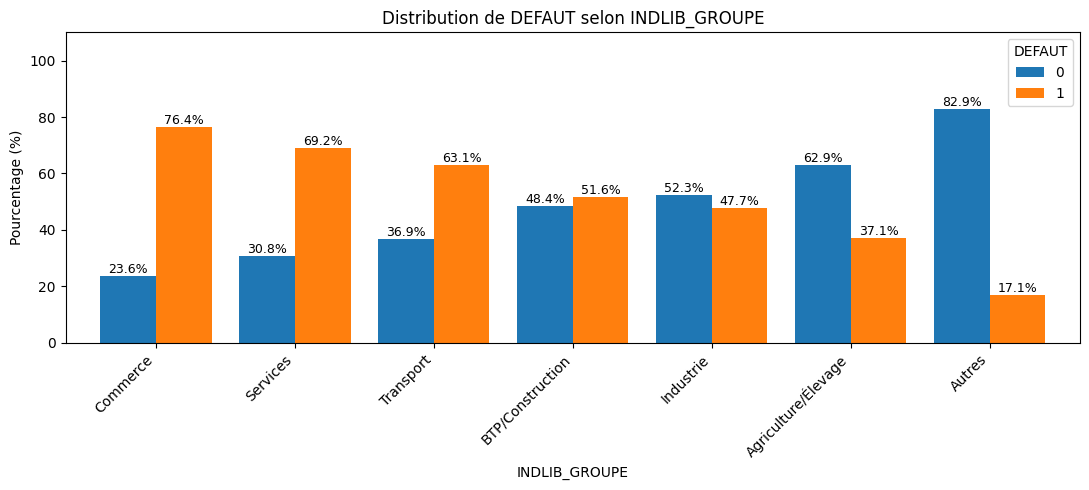

In [5]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(11, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel(variable)
plt.ylabel('Pourcentage (%)')
plt.title(f'Distribution de {target} selon {variable}')
plt.xticks(rotation=45, ha='right')
plt.legend(title=target)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [7]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print(f"Conclusion : Il existe une relation significative entre {variable} et {target}.")
else:
    print(f"Conclusion : Il n'existe pas de relation significative entre {variable} et {target}.")

Statistique Chi-square : 4174.537
p-value : 0.0
Degrés de liberté : 6
Conclusion : Il existe une relation significative entre INDLIB_GROUPE et DEFAUT.


In [8]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.4019
Interprétation : La force de la relation est modérée.


### DEFAUT x PORTEF

In [9]:
variable = 'PORTEF'
target = 'DEFAUT'

In [10]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
PORTEF,,
CAM,6756 (91.84%),600 (8.16%)
DD,50 (58.82%),35 (41.18%)
DDC,1605 (89.77%),183 (10.23%)
FSE,2941 (43.41%),3834 (56.59%)
PP,980 (11.24%),7741 (88.76%)
PROJ_M_AV,62 (11.74%),466 (88.26%)
PROPEP,116 (19.5%),479 (80.5%)


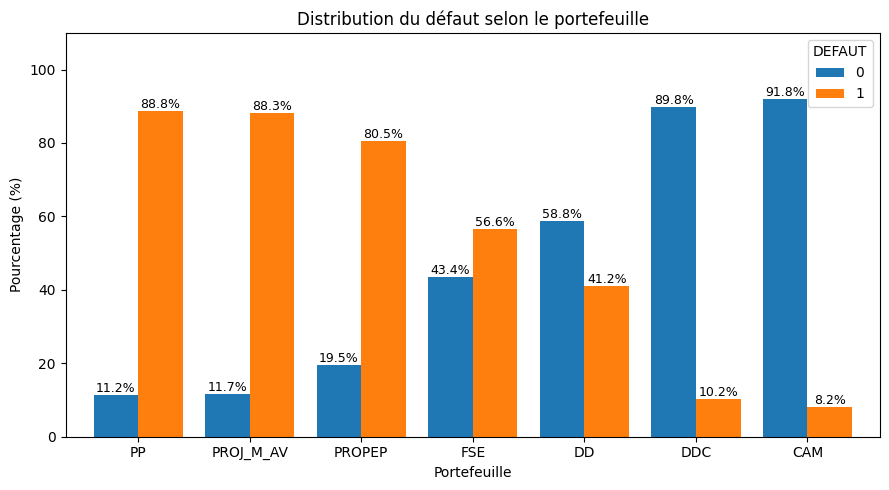

In [11]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Portefeuille')
plt.ylabel('Pourcentage (%)')
plt.title('Distribution du défaut selon le portefeuille')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [14]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre PORTEF et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre PORTEF et DEFAUT.")

Statistique Chi-square : 12161.0667
p-value : 0.0
Degrés de liberté : 6
Conclusion : Il existe une relation significative entre PORTEF et DEFAUT.


In [15]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.6859
Interprétation : La force de la relation est forte.


### DEFAUT x PERIODE

In [16]:
variable = 'PERIODE'
target = 'DEFAUT'

In [17]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
PERIODE,,
M,5873 (31.52%),12762 (68.48%)
S,6578 (93.27%),475 (6.73%)
T,59 (36.88%),101 (63.12%)


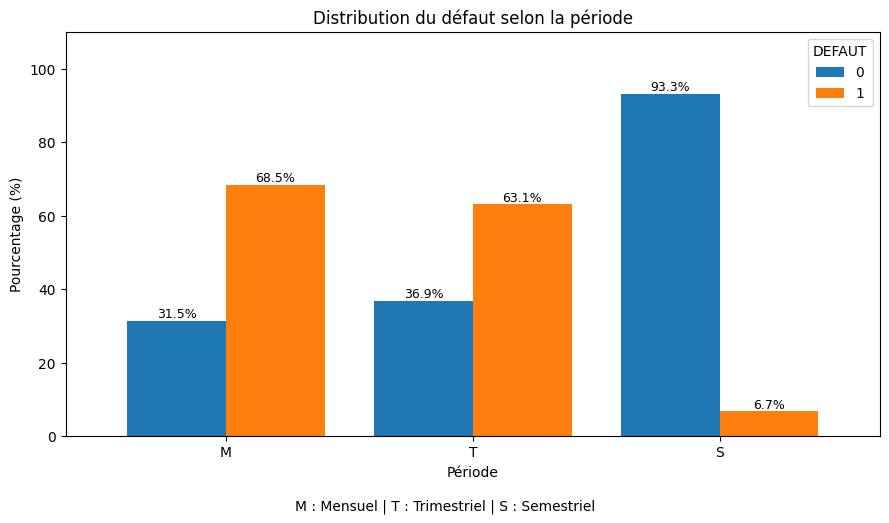

In [20]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Période')
plt.ylabel('Pourcentage (%)')
plt.title('Distribution du défaut selon la période')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)

plt.figtext(
    0.5, -0.03,
    "M : Mensuel | T : Trimestriel | S : Semestriel",
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

In [21]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre PERIODE et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre PERIODE et DEFAUT.")

Statistique Chi-square : 7820.2161
p-value : 0.0
Degrés de liberté : 2
Conclusion : Il existe une relation significative entre PERIODE et DEFAUT.


In [22]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.55
Interprétation : La force de la relation est forte.


### DEFAUT x SEX

In [23]:
variable = 'SEX'
target = 'DEFAUT'

In [24]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
SEX,,
Female,2925 (31.14%),6469 (68.86%)
Male,9585 (58.25%),6869 (41.75%)


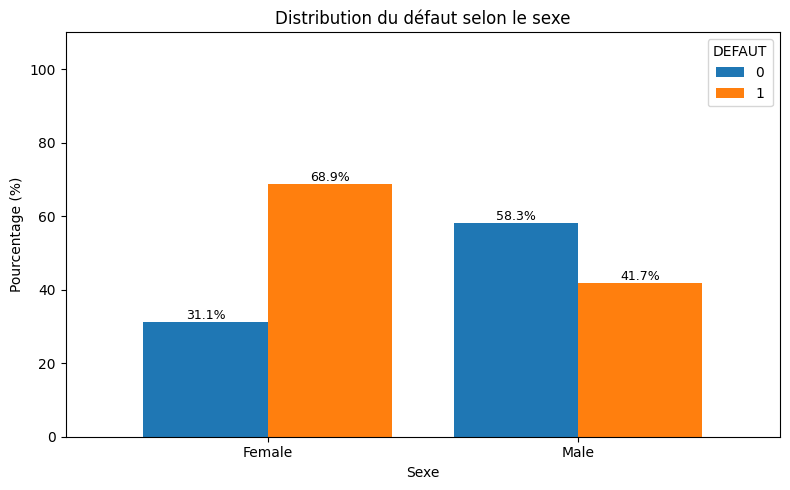

In [25]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(8, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Sexe')
plt.ylabel('Pourcentage (%)')
plt.title('Distribution du défaut selon le sexe')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [28]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre SEX et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre SEX et DEFAUT.")

Statistique Chi-square : 1759.5341
p-value : 0.0
Degrés de liberté : 1
Conclusion : Il existe une relation significative entre SEX et DEFAUT.


In [29]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.2609
Interprétation : La force de la relation est faible.


### DEFAUT x AGENCE_LIEU

In [30]:
variable = 'AGENCE_LIEU'
target = 'DEFAUT'

In [31]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
AGENCE_LIEU,,
Adrar,471 (40.39%),695 (59.61%)
Assaba,204 (13.34%),1325 (86.66%)
Brakna,957 (33.48%),1901 (66.52%)
Dakhlet Nouadhibou,611 (59.49%),416 (40.51%)
Gorgol,1580 (47.5%),1746 (52.5%)
Guidimagha,139 (11.49%),1071 (88.51%)
Hodh Chargui,265 (14.85%),1519 (85.15%)
Hodh Gharbi,211 (15.9%),1116 (84.1%)
Inchiri,131 (17.82%),604 (82.18%)


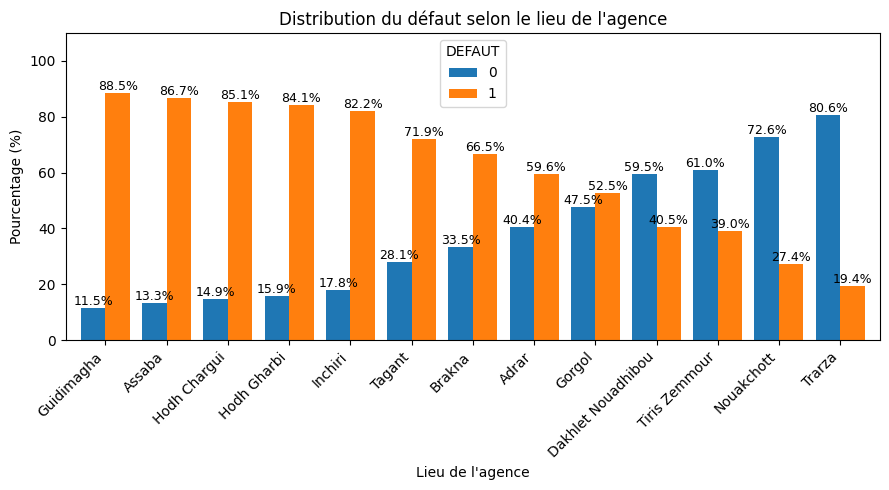

In [32]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel("Lieu de l'agence")
plt.ylabel('Pourcentage (%)')
plt.title("Distribution du défaut selon le lieu de l'agence")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [33]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre AGENCE_LIEU et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre AGENCE_LIEU et DEFAUT.")

Statistique Chi-square : 6969.6235
p-value : 0.0
Degrés de liberté : 12
Conclusion : Il existe une relation significative entre AGENCE_LIEU et DEFAUT.


In [34]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.5193
Interprétation : La force de la relation est forte.


### DEFAUT x ETATCIVIL

In [35]:
variable = 'ETATCIVIL'
target = 'DEFAUT'

In [36]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
ETATCIVIL,,
Divorced,241 (25.53%),703 (74.47%)
Married,10486 (53.27%),9199 (46.73%)
Single,1783 (34.16%),3436 (65.84%)


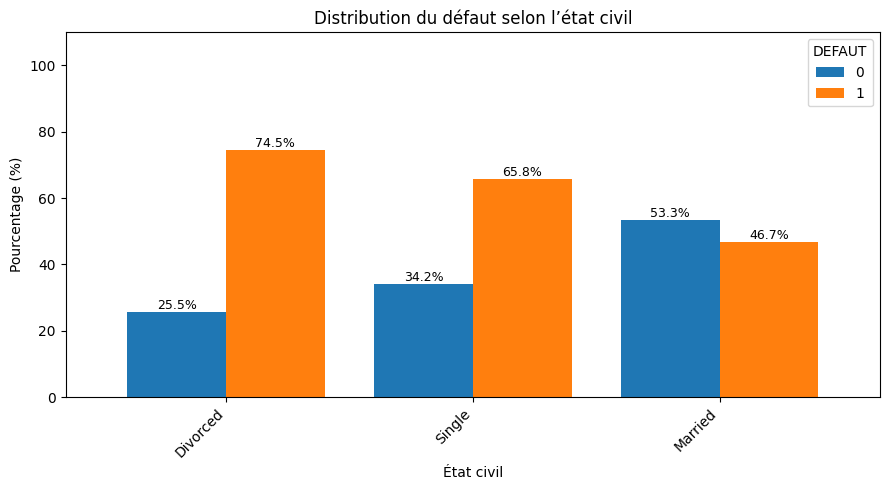

In [37]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel("État civil")
plt.ylabel("Pourcentage (%)")
plt.title("Distribution du défaut selon l’état civil")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [39]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre ETATCIVIL et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre ETATCIVIL et DEFAUT.")

Statistique Chi-square : 808.1055
p-value : 3.327524454192334e-176
Degrés de liberté : 2
Conclusion : Il existe une relation significative entre ETATCIVIL et DEFAUT.


In [40]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.1768
Interprétation : La force de la relation est faible.


### DEFAUT x WILAYA_NAISSANCE

In [41]:
variable = 'WILAYA_NAISSANCE'
target = 'DEFAUT'

In [42]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
WILAYA_NAISSANCE,,
Adrar,850 (55.09%),693 (44.91%)
Assaba,508 (27.02%),1372 (72.98%)
Brakna,1336 (42.89%),1779 (57.11%)
Gorgol,1606 (50.5%),1574 (49.5%)
Guidimakha,272 (20.7%),1042 (79.3%)
Hodh Ech Chargui,372 (19.85%),1502 (80.15%)
Hodh el Gharbi,400 (64.62%),219 (35.38%)
Inchiri,185 (22.59%),634 (77.41%)
Inconnu,2421 (58.58%),1712 (41.42%)


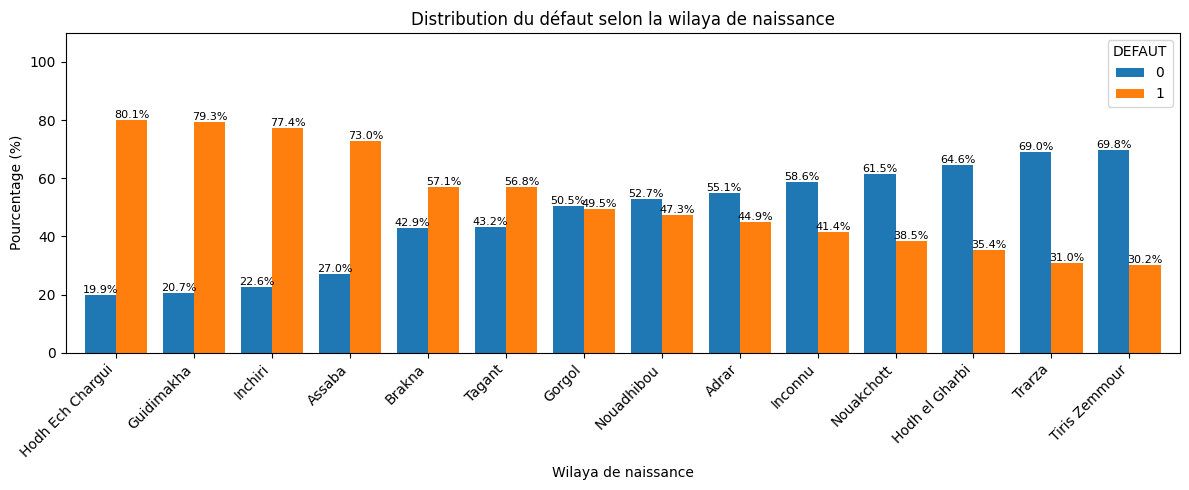

In [43]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(12, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=8
    )

plt.xlabel("Wilaya de naissance")
plt.ylabel("Pourcentage (%)")
plt.title("Distribution du défaut selon la wilaya de naissance")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [44]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :",p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre WILAYA_NAISSANCE et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre WILAYA_NAISSANCE et DEFAUT.")

Statistique Chi-square : 2701.0157
p-value : 0.0
Degrés de liberté : 13
Conclusion : Il existe une relation significative entre WILAYA_NAISSANCE et DEFAUT.


In [45]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.3233
Interprétation : La force de la relation est modérée.


In [46]:
df.duplicated().sum()

np.int64(172)

## Variables Quantitatives

### NIVEAU_RISQUE x MONTANT

In [40]:
df.groupby("NIVEAU_RISQUE")["MONTANT"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,2375415.74,1100000.0,100000.0,23779970.87,3267500.80
Moyen,249,2260723.43,1100000.0,150000.0,19176421.58,2673545.00
Élevé,248,2238539.82,1000000.0,160000.0,41018068.50,4154335.55


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\2869201662.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


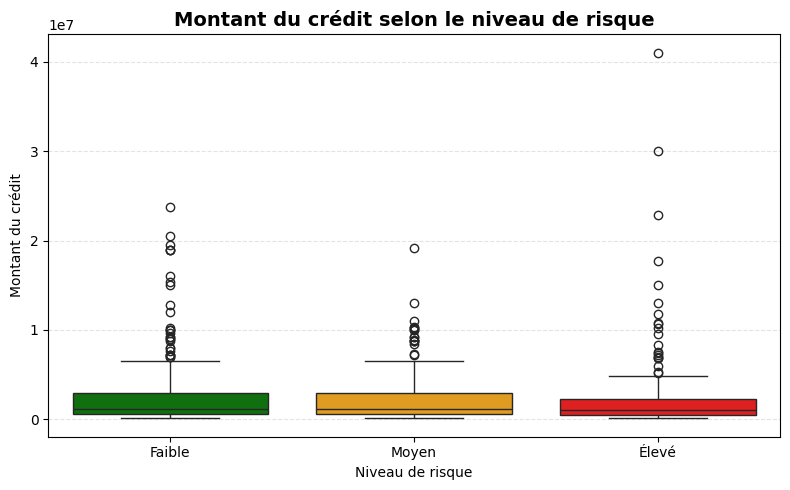

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="MONTANT",
    order=ordre,
    palette=couleurs
)

plt.title("Montant du crédit selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Montant du crédit")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [47]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "MONTANT"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "MONTANT"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "MONTANT"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative du montant selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative du montant selon le niveau de risque.")

Statistique Kruskal-Wallis : 5.531547404798422
p-value : 0.06292739343322779
Il n'existe pas de différence statistiquement significative du montant selon le niveau de risque.


### NIVEAU_RISQUE x DUREE

In [48]:
df.groupby("NIVEAU_RISQUE")["DUREE"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,51.35,48.0,8,144,10.59
Moyen,249,51.04,48.0,22,84,7.37
Élevé,248,50.74,48.0,24,96,9.23


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\3877209556.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


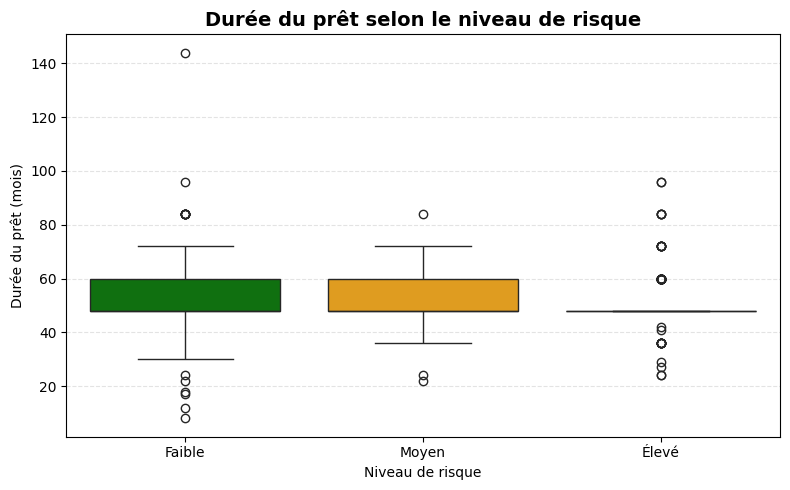

In [ ]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="DUREE",
    order=ordre,
    palette=couleurs
)

plt.title("Durée du prêt selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Durée du prêt (mois)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [51]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "DUREE"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "DUREE"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "DUREE"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative de la durée du prêt selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative de la durée du prêt selon le niveau de risque.")

Statistique Kruskal-Wallis : 2.6450394875301457
p-value : 0.26646303677798916
Il n'existe pas de différence statistiquement significative de la durée du prêt selon le niveau de risque.


### NIVEAU_RISQUE x TAUX_INT

In [52]:
df.groupby("NIVEAU_RISQUE")["TAUX_INT"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,9.29,10.0,0.0,10.0,1.94
Moyen,249,9.23,10.0,0.0,10.0,2.26
Élevé,248,9.19,10.0,0.0,10.0,2.35


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\2009331003.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


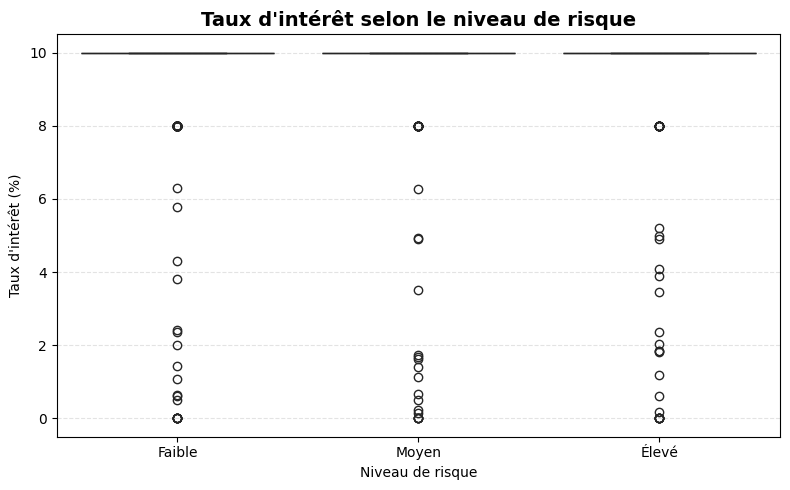

In [57]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="TAUX_INT",
    order=ordre,
    palette=couleurs
)

plt.title("Taux d'intérêt selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Taux d'intérêt (%)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

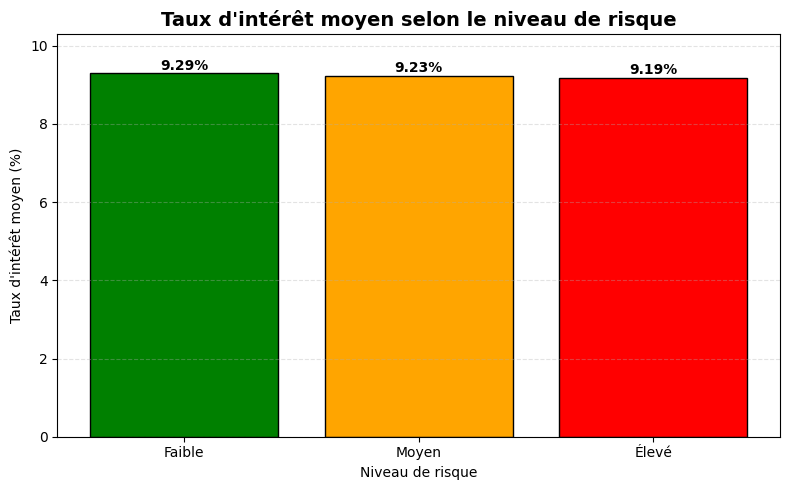

In [59]:
ordre = ["Faible", "Moyen", "Élevé"]

moyennes = df.groupby("NIVEAU_RISQUE")["TAUX_INT"].mean().reindex(ordre)

couleurs = ["green", "orange", "red"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    moyennes.index,
    moyennes.values,
    color=couleurs,
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Taux d'intérêt moyen selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Taux d'intérêt moyen (%)")
plt.ylim(0, moyennes.max() + 1)
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [60]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "TAUX_INT"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "TAUX_INT"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "TAUX_INT"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative du taux d'intérêt selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative du taux d'intérêt selon le niveau de risque.")

Statistique Kruskal-Wallis : 2.459281149592476
p-value : 0.2923976538825367
Il n'existe pas de différence statistiquement significative du taux d'intérêt selon le niveau de risque.


### NIVEAU_RISQUE x NB_ECH

In [61]:
df.groupby("NIVEAU_RISQUE")["NB_ECH"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,40.24,48.0,4,84,12.95
Moyen,249,40.98,48.0,12,82,11.80
Élevé,248,42.54,48.0,4,96,11.75


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\110906037.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


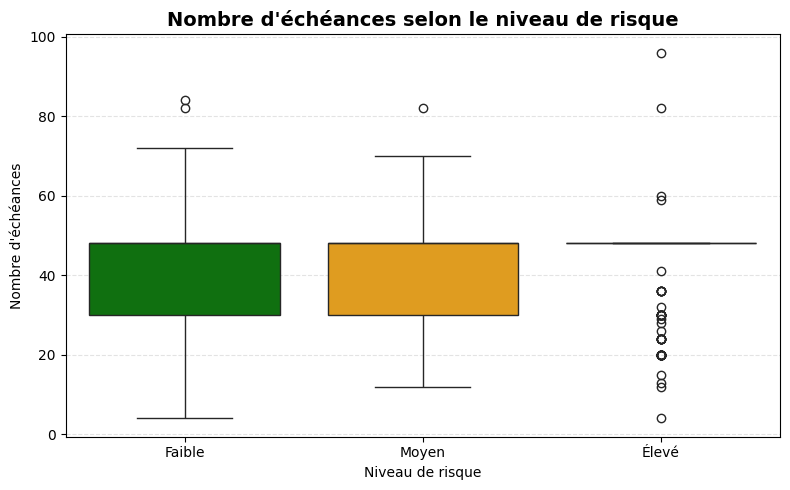

In [63]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="NB_ECH",
    order=ordre,
    palette=couleurs
)

plt.title("Nombre d'échéances selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre d'échéances")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [64]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "NB_ECH"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "NB_ECH"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "NB_ECH"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative du nombre d'échéances selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative du nombre d'échéances selon le niveau de risque.")

Statistique Kruskal-Wallis : 5.585301014768823
p-value : 0.0612586320913017
Il n'existe pas de différence statistiquement significative du nombre d'échéances selon le niveau de risque.


### NIVEAU_RISQUE x VALEURGARANT

In [65]:
df.groupby("NIVEAU_RISQUE")["VALEURGARANT"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,6415342.24,3073500.0,100000,75808020,9641940.00
Moyen,249,5027951.74,2940000.0,296000,75808020,6625822.65
Élevé,248,3867224.74,1758125.0,141000,40000000,5375176.08


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\1653975806.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


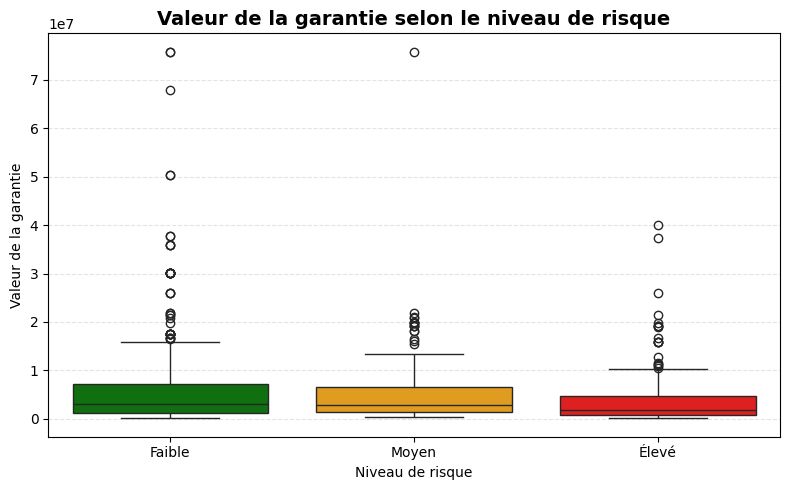

In [67]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="VALEURGARANT",
    order=ordre,
    palette=couleurs
)

plt.title("Valeur de la garantie selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Valeur de la garantie")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [68]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "VALEURGARANT"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "VALEURGARANT"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "VALEURGARANT"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative de la valeur de la garantie selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative de la valeur de la garantie selon le niveau de risque.")

Statistique Kruskal-Wallis : 23.292935516995566
p-value : 8.749904617618346e-06
Il existe une différence statistiquement significative de la valeur de la garantie selon le niveau de risque.


### NIVEAU_RISQUE x AGE

In [69]:
df.groupby("NIVEAU_RISQUE")["AGE"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,54.95,56.0,23,85,11.10
Moyen,249,51.22,52.0,28,77,10.71
Élevé,248,53.54,53.0,26,80,11.00


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\4021540090.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


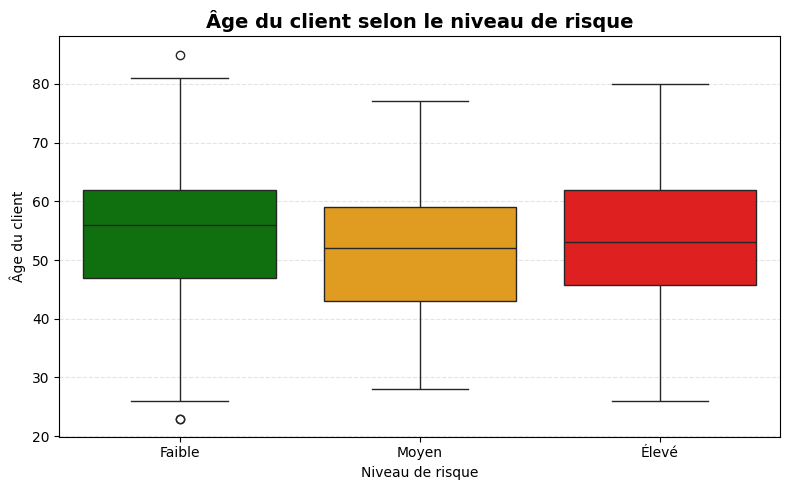

In [70]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="AGE",
    order=ordre,
    palette=couleurs
)

plt.title("Âge du client selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Âge du client")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [71]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "AGE"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "AGE"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "AGE"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative de l'âge selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative de l'âge selon le niveau de risque.")

Statistique Kruskal-Wallis : 17.29367164361072
p-value : 0.00017568185832436434
Il existe une différence statistiquement significative de l'âge selon le niveau de risque.


# Clustering

In [72]:
# Les variables de clustering
variables_cluster = [
    "MONTANT",
    "DUREE",
    "TAUX_INT",
    "NB_ECH",
    "VALEURGARANT",
    "AGE"
]

In [73]:
# Preparer les donner pour le clustering
from sklearn.preprocessing import StandardScaler

X = df[variables_cluster].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

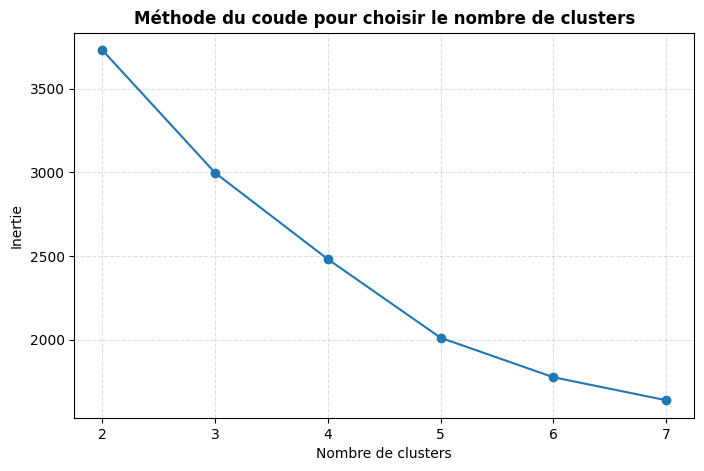

In [74]:
# Trouver le meuiler numéro de clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertias, marker="o")
plt.title("Méthode du coude pour choisir le nombre de clusters", fontweight="bold")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [75]:
# Appliquer le K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["CLUSTER"] = kmeans.fit_predict(X_scaled)

In [76]:
df.groupby("CLUSTER")[variables_cluster].mean().round(2)

,MONTANT,DUREE,TAUX_INT,NB_ECH,VALEURGARANT,AGE
CLUSTER,,,,,,
0,1072640.65,47.63,9.77,47.63,2465806.06,52.84
1,5739477.51,62.53,9.55,24.21,13570544.87,54.42
2,2588705.12,43.94,1.31,33.44,4877408.30,58.42


In [77]:
df["CLUSTER"].value_counts()

CLUSTER
0    632
1    223
2     50
Name: count, dtype: int64

In [78]:
# Comparer les clusters avec le niveau du risque. 
pd.crosstab(
    df["CLUSTER"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

NIVEAU_RISQUE,Faible,Moyen,Élevé
CLUSTER,,,
0,43.83,26.74,29.43
1,51.12,28.70,20.18
2,34.00,32.00,34.00
